In [367]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

import feature_lists_v2 as fl

In [368]:
df=pd.read_csv("../../data/processed/v2/top5leagues_sofaascore_processed_2526.csv")

In [369]:
strikers=df[(df["position"] == "Forwards") & (df["minutesPlayed"] >= 450)].copy()

In [370]:
strikers=strikers.drop(columns=fl.goalkeeper_features)

In [371]:
strikers=strikers.drop(columns=fl.discipline_features)

In [372]:
strikers=strikers.drop(columns=[
    "fouls",
    "fouls_per90",
    "tackles",
    "tacklesWon",
    "tacklesWonPercentage",
    "possessionWonAttThird",
    "clearances",
    "blockedShots",
    "dribbledPast",
    "errorLeadToShot",
    "errorLeadToGoal",
    "tackles_per90",
    "tacklesWon_per90",
    "possessionWonAttThird_per90",
    "clearances_per90",
    "blockedShots_per90",
    "dribbledPast_per90",
    "errorLeadToShot_per90",
    "errorLeadToGoal_per90",
    
    ])

In [373]:
strikers.shape

(414, 145)

In [374]:
striker_desc=strikers.drop(columns=fl.metadata_features).describe().transpose()

In [375]:
striker_desc.columns

Index(['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'], dtype='str')

In [376]:
striker_desc['cv']=striker_desc['std']/striker_desc['mean']

In [377]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(striker_desc['cv'])

accurateChippedPasses                  1.107776
accurateCrosses                        1.446273
accurateCrossesPercentage              0.867787
accurateFinalThirdPasses               0.741113
accurateLongBalls                      1.079194
accurateLongBallsPercentage            0.389510
accurateOppositionHalfPasses           0.708308
accurateOwnHalfPasses                  0.658629
accuratePasses                         0.668276
accuratePassesPercentage               0.099569
aerialDuelsWon                         1.134013
aerialDuelsWonPercentage               0.355872
aerialLost                             0.866344
appearances                            0.290505
assists                                0.964490
ballRecovery                           0.595567
bigChancesCreated                      0.911290
bigChancesMissed                       0.813749
countRating                            0.297730
dispossessed                           0.624977
duelLost                               0

In [378]:
strikers=strikers.drop(columns=[
    'rating',
    'totalRating',
    'countRating',
    'accuratePassesPercentage', 
    'opp_half_pass_pct',
])

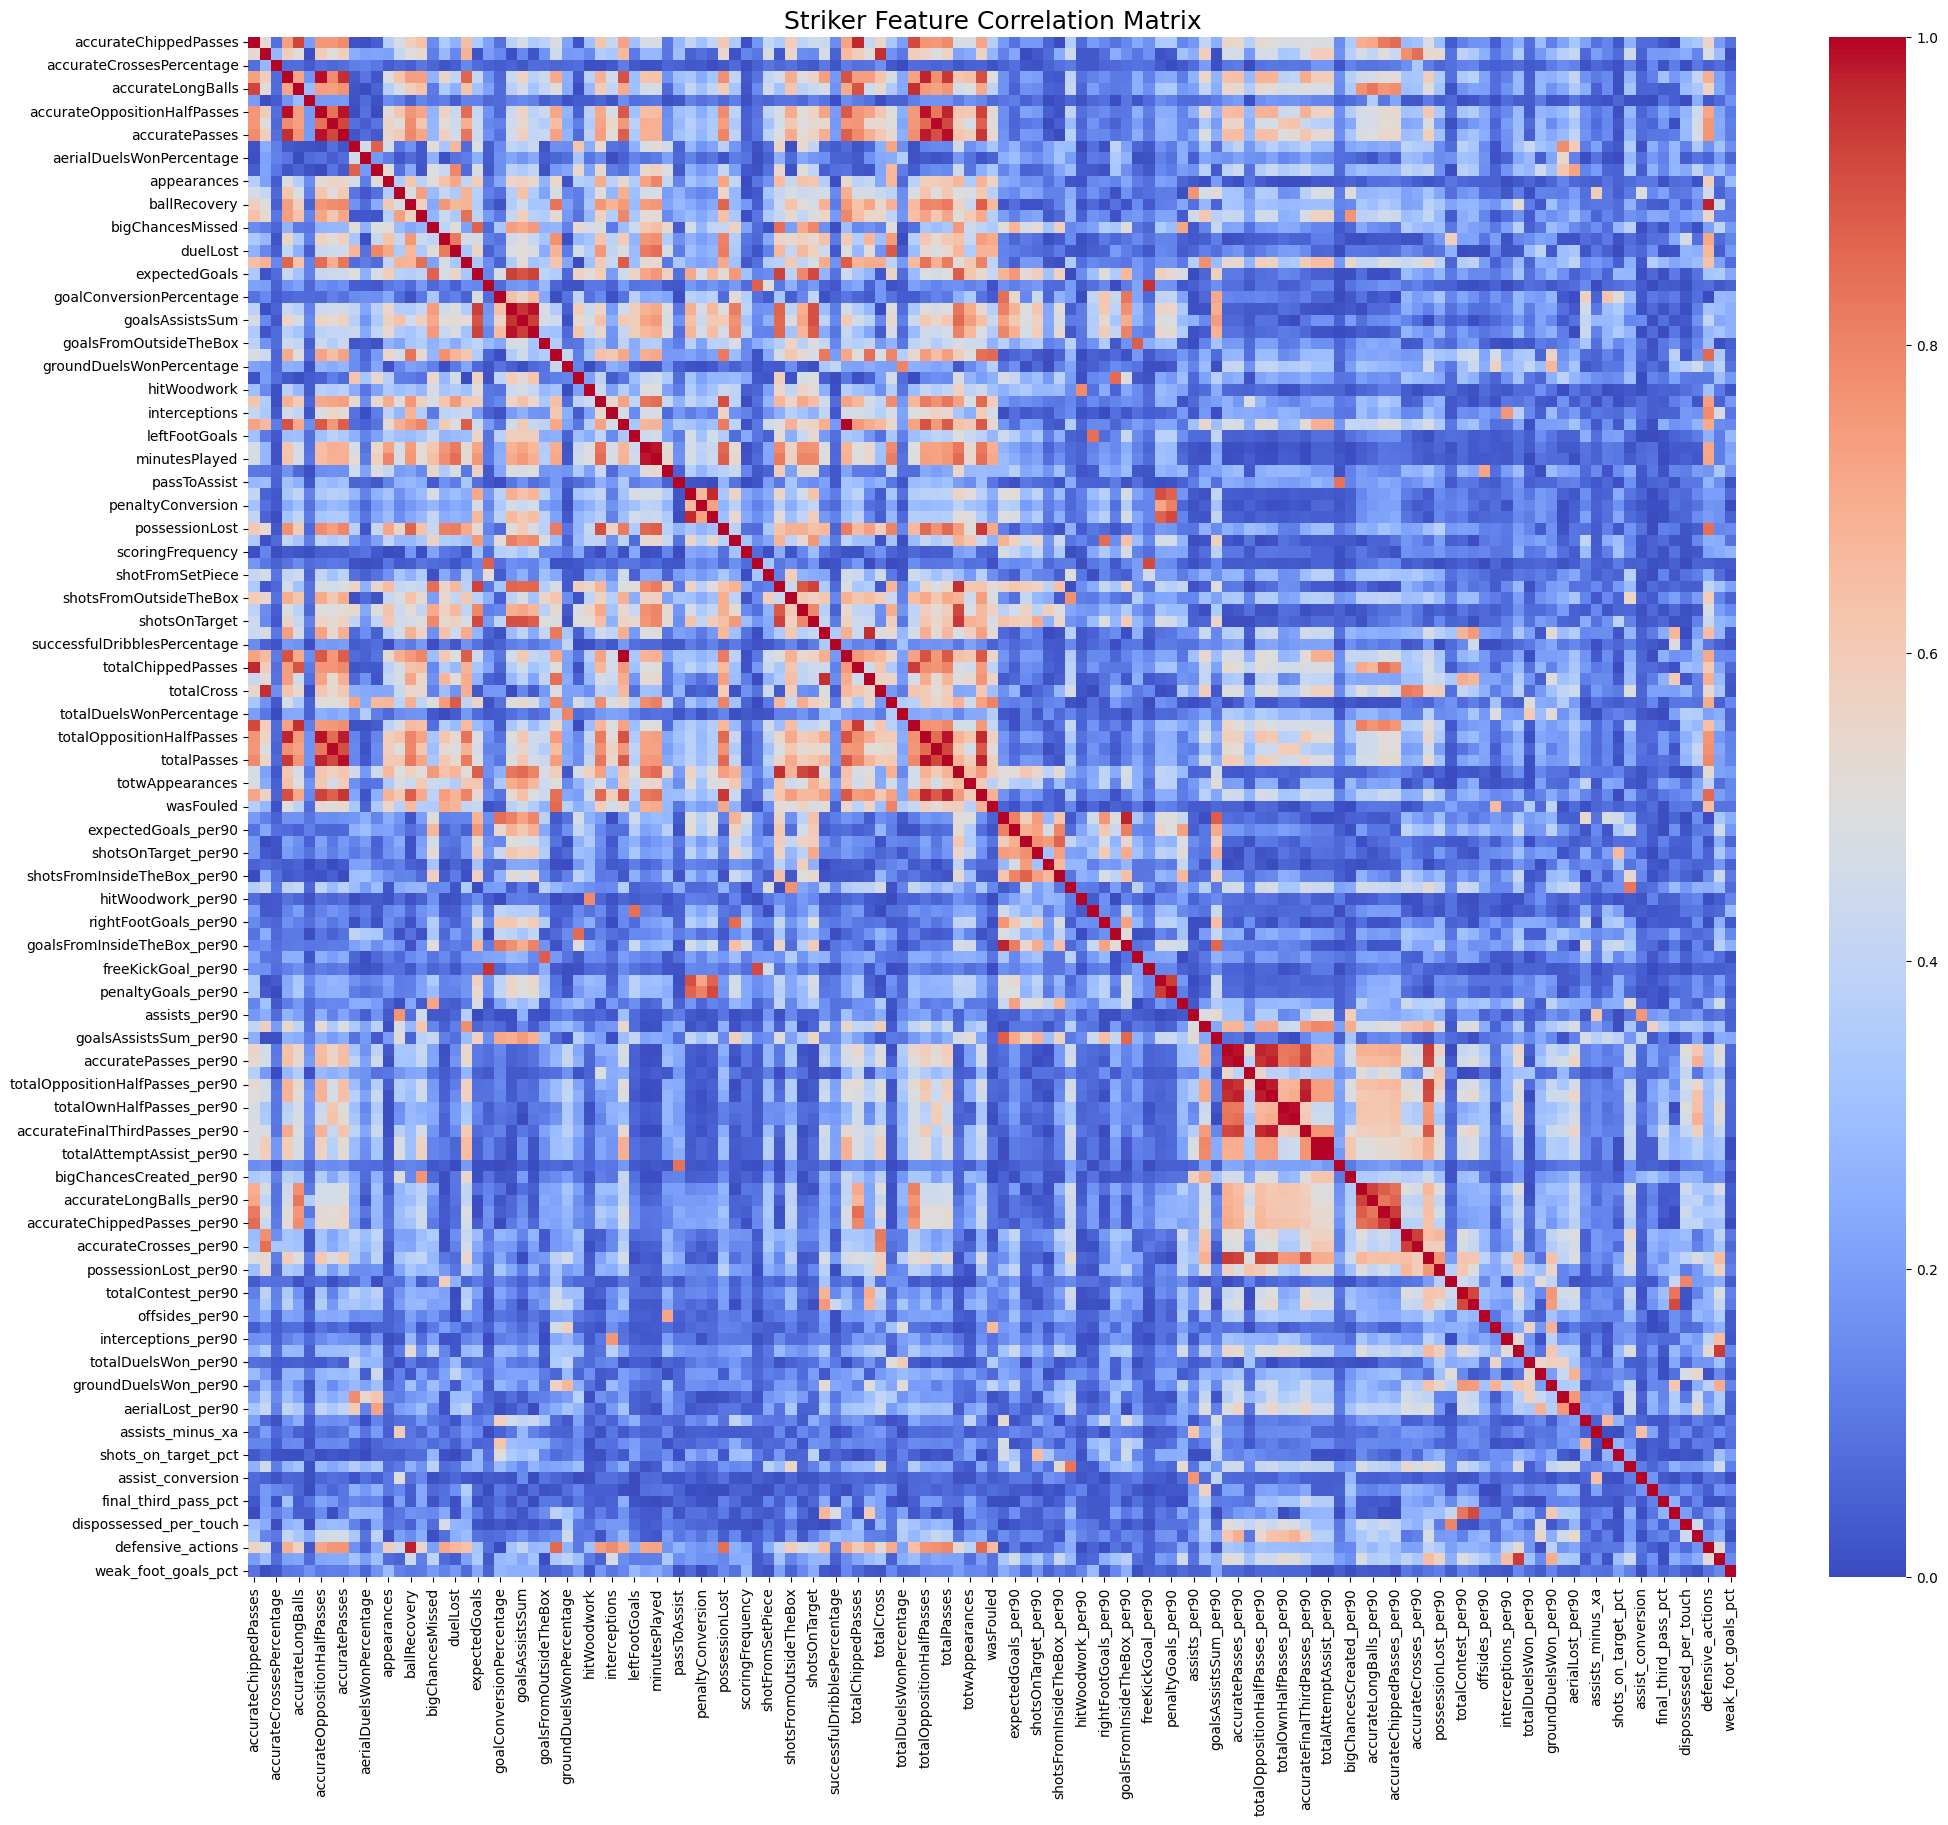

In [379]:

corr_matrix = strikers.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [380]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,keyPasses,totalAttemptAssist,0.999618
1,keyPasses_per90,totalAttemptAssist_per90,0.998890
2,accurateOwnHalfPasses,totalOwnHalfPasses,0.993735
3,totalOwnHalfPasses_per90,accurateOwnHalfPasses_per90,0.989588
4,accurateFinalThirdPasses,accurateOppositionHalfPasses,0.989063
5,accuratePasses,totalPasses,0.988587
6,totalOppositionHalfPasses,totalPasses,0.987986
7,goals,goalsFromInsideTheBox,0.985752
8,accurateOppositionHalfPasses,accuratePasses,0.985150
9,totalPasses_per90,accuratePasses_per90,0.985000


In [381]:
cat='weak_foot_goals_pct'

In [382]:
strikers[strikers['goals']>8][['player','team',cat,'goals']].nlargest(20, 'goals')

,player,team,weak_foot_goals_pct,goals
1510,Harry Kane,FC Bayern München,0.181818,36
433,Erling Haaland,Manchester City,0.125000,27
1019,Kylian Mbappé,Real Madrid,0.080000,25
1025,Vedat Muriqi,Mallorca,0.312500,23
442,Igor Thiago,Brentford,0.300000,22
2639,Esteban Lepaul,Stade Rennais,0.111111,21
1512,Deniz Undav,VfB Stuttgart,0.111111,19
1047,Ante Budimir,Osasuna,0.166667,17
1530,Serhou Guirassy,Borussia Dortmund,0.083333,17
2073,Lautaro Martínez,Inter,0.384615,17


In [383]:
strikers=strikers.drop(columns=[
    'totalAttemptAssist',
    'totalAttemptAssist_per90',
    'accurateOwnHalfPasses',
    'totalOwnHalfPasses',
    'accurateOwnHalfPasses_per90',
    'accurateOppositionHalfPasses',
    'accuratePasses',
    'totalOppositionHalfPasses',
    'accuratePasses_per90',
    'matchesStarted',
    'accurateFinalThirdPasses_per90',
    'ballRecovery',
    'accurateOppositionHalfPasses_per90',
    'totalPasses',
    'totalOppositionHalfPasses_per90',
    'accurateChippedPasses',
    'penaltiesTaken',
    'accurateCrosses',
    'totalContest',
    'totalLongBalls',
    'shotsFromInsideTheBox',
    'freeKickGoal_per90',
    'goalsAssistsSum',
    'possessionLost',
    'ballRecovery_per90',
    'totalChippedPasses_per90',
    'penaltiesTaken_per90',
    'goalsFromInsideTheBox',
    'goalsFromInsideTheBox_per90',
    'totalShots',
    'totalPasses_per90',
    'totalCross_per90',
    'totalLongBalls_per90',
    'goals',
    'touches',
    'accurateFinalThirdPasses',
    'expectedAssists',
    'penaltyGoals', 
    'goalsFromOutsideTheBox', 
    'headedGoals', 
    'rightFootGoals', 
    'leftFootGoals', 
    'accurateLongBalls', 
    'totalChippedPasses', 
    'passToAssist',
    'totalContest_per90', 
    'dribbles_per_touch',
    'minutesPlayed', 
    'appearances',
    'freeKickGoal', 
    'totalCross',
    'shotsFromOutsideTheBox_per90',
    'aerialDuelsWon', 
    'assists', 
    'bigChancesCreated', 
    'bigChancesMissed', 
    'dispossessed', 
    'duelLost', 
    'expectedGoals', 
    'groundDuelsWon', 
    'inaccuratePasses', 
    'interceptions', 
    'keyPasses', 
    'successfulDribbles', 
    'totalDuelsWon', 
    'wasFouled', 
    'defensive_actions', 
    'shotFromSetPiece', 
    'hitWoodwork',
    'scoringFrequency', 
    'goals_per_xg', 
    'totalOwnHalfPasses_per90',
    'setPieceConversion', 
    'totwAppearances', 
    'penaltyConversion',
    'aerialLost', 
    'shotsFromOutsideTheBox', 
    'shotsOffTarget', 
    'shotsOnTarget', 
    'shotsOnTarget_per90',
    'goalsAssistsSum_per90',
    'shotsFromInsideTheBox_per90',
    "accurateChippedPasses_per90",
    'leftFootGoals_per90', 
    'rightFootGoals_per90',
    'hitWoodwork_per90'
])

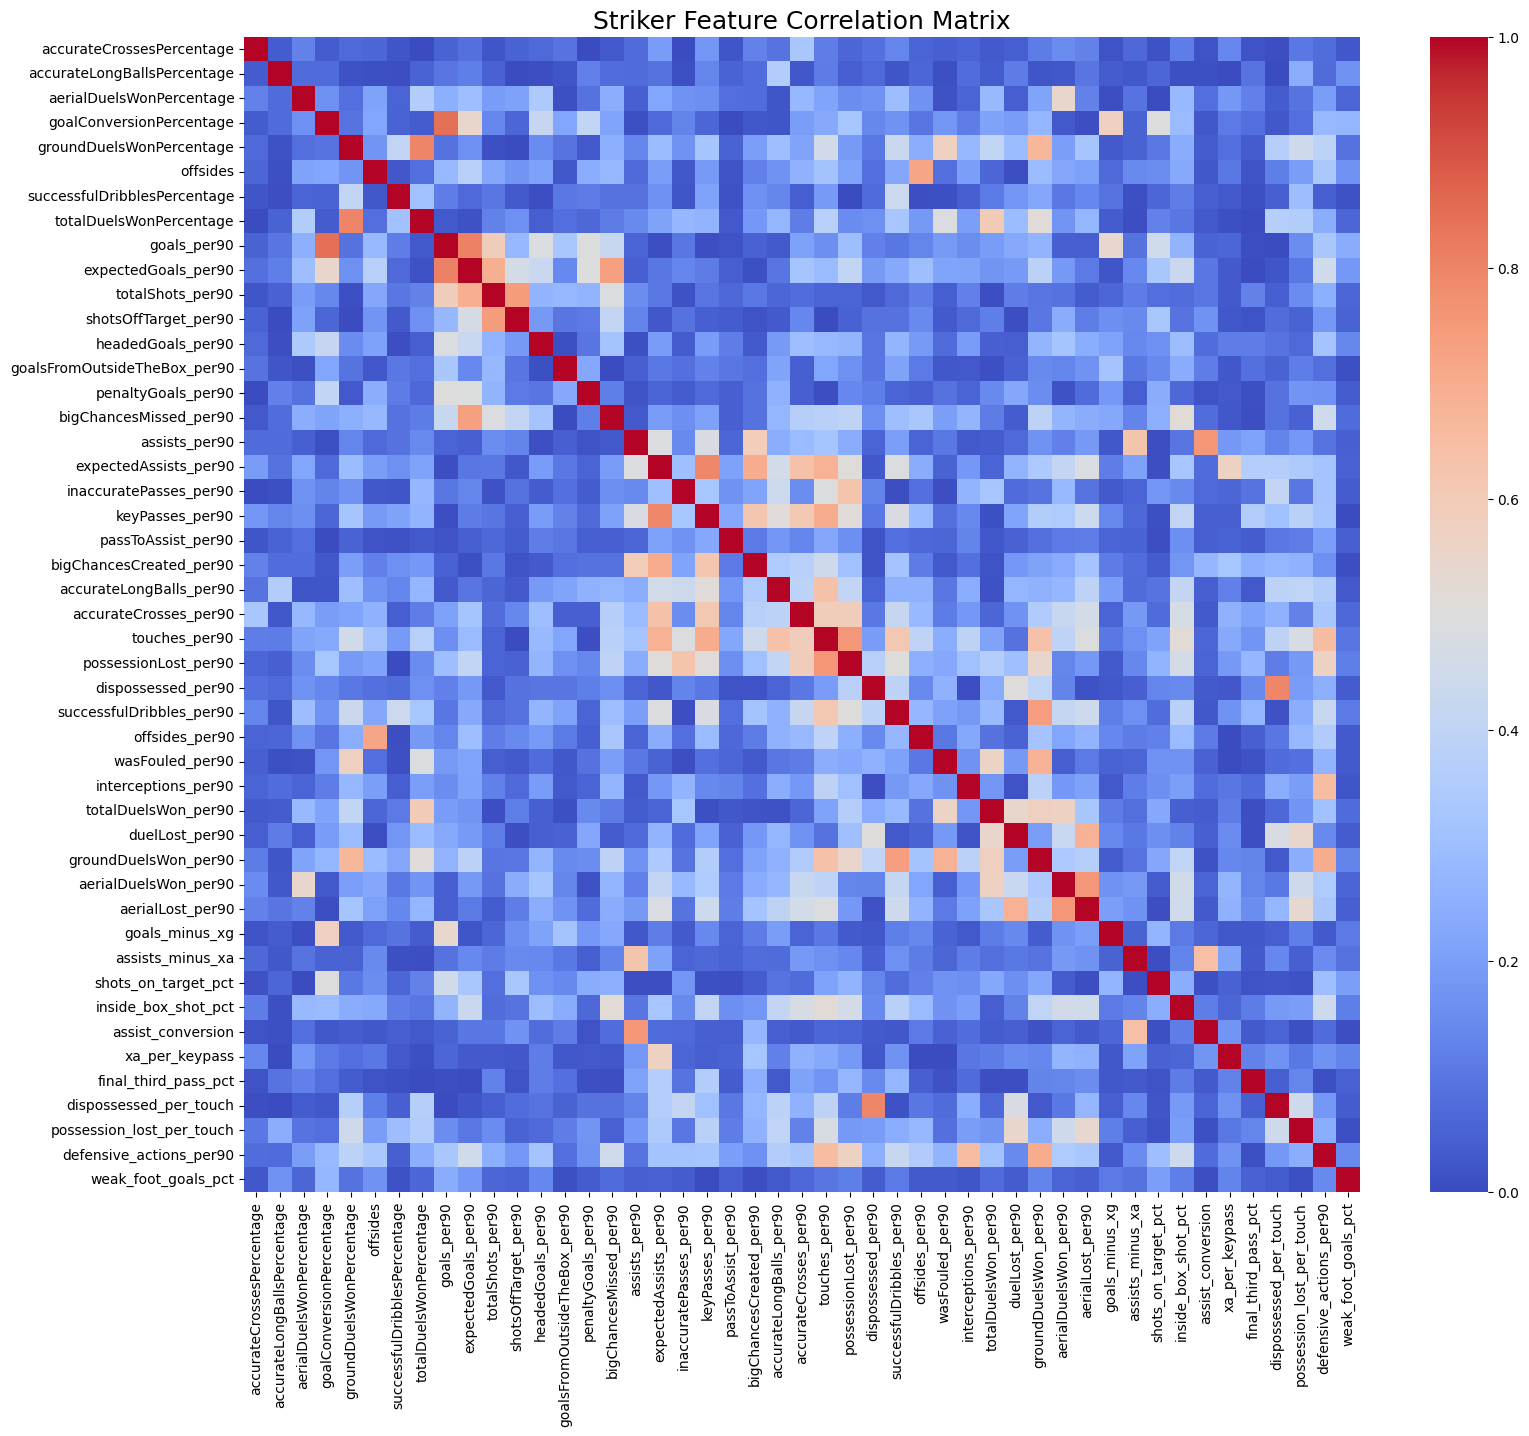

In [384]:
corr_matrix = strikers.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [385]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,goalConversionPercentage,goals_per90,0.841880
1,goals_per90,expectedGoals_per90,0.805334


In [386]:
strikers.shape

(414, 54)

In [387]:
print(strikers.columns.tolist())

['accurateCrossesPercentage', 'accurateLongBallsPercentage', 'aerialDuelsWonPercentage', 'goalConversionPercentage', 'groundDuelsWonPercentage', 'offsides', 'successfulDribblesPercentage', 'totalDuelsWonPercentage', 'player', 'team', 'player id', 'team id', 'league', 'season', 'position', 'goals_per90', 'expectedGoals_per90', 'totalShots_per90', 'shotsOffTarget_per90', 'headedGoals_per90', 'goalsFromOutsideTheBox_per90', 'penaltyGoals_per90', 'bigChancesMissed_per90', 'assists_per90', 'expectedAssists_per90', 'inaccuratePasses_per90', 'keyPasses_per90', 'passToAssist_per90', 'bigChancesCreated_per90', 'accurateLongBalls_per90', 'accurateCrosses_per90', 'touches_per90', 'possessionLost_per90', 'dispossessed_per90', 'successfulDribbles_per90', 'offsides_per90', 'wasFouled_per90', 'interceptions_per90', 'totalDuelsWon_per90', 'duelLost_per90', 'groundDuelsWon_per90', 'aerialDuelsWon_per90', 'aerialLost_per90', 'goals_minus_xg', 'assists_minus_xa', 'shots_on_target_pct', 'inside_box_shot_p

In [388]:
strikers.select_dtypes(include=['number']).isna().sum().sum()

np.int64(40)

In [389]:
strikers['weak_foot_goals_pct'] = strikers['weak_foot_goals_pct'].fillna(0)
strikers['assist_conversion'] = strikers['assist_conversion'].fillna(0)
strikers['xa_per_keypass'] = strikers['xa_per_keypass'].fillna(0)

In [ ]:
#strikers.to_csv("../../data/processed/v2/strikers_top5leagues_sofascore2526.csv",index=False)